# Scrape Google Trends for Your Own Topic - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 1, 3:30 session.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI) to pull Google Trends for **your own** disease and place.

> We use the **Google Trends API** rather than scraping. Same normalized 0-100 signal as
> `pytrends`, but from a documented API: no HTTP 429s, and the same numbers every pull.
> Unlock the key first in the terminal: `source scripts/unlock-gt-api-key.sh` (Google Trends passcode),
> which exports `GT_API`. Never paste a key into a notebook you will share.


## Step 0: build a reliable fetch, and pick your topic

> *Write `gt_api_fetch(terms, geo, start, end)` that calls the Google Trends API endpoint*
> *`https://www.googleapis.com/trends/v1beta/graph` with query parameters `key`, repeated*
> *`terms`, `restrictions.geo`, `restrictions.startDate` and `restrictions.endDate`*
> *(dates are YYYY-MM). Read the key from the GT_API environment variable, never hardcode*
> *it. Parse the JSON `lines[].points[]` into a tidy DataFrame: a date column plus one*
> *column per term. Add a `gt_fetch` wrapper that falls back to the cached CSV in data/*
> *if the key is missing. Then set MY_TERMS and MY_GEO for me to edit.*


In [ ]:
# Paste the agent's helpers + your MY_TERMS / MY_GEO here.


## Step 1: pull your topic

> *Use gt_fetch to pull MY_TERMS for MY_GEO over about the last five years. Plot the*
> *series, print the date range, and tell me whether Google returned weekly or monthly*
> *points and why.*

**Your check:** does the last point land near today, and do the peaks fall in a plausible
season for your disease and place?


Topic for 'mazelen': 'Measles' (Disease), mid=/m/0g2gb
Rows: 105 | last date: 2025-12-28


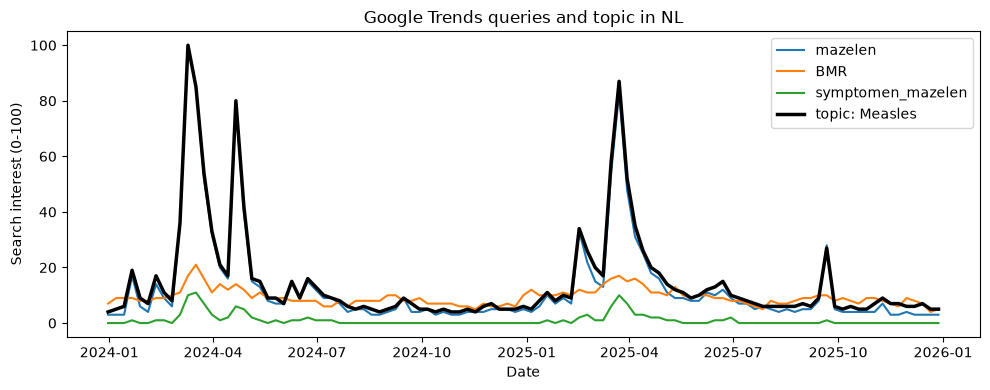

Daily window 1/12: 2023-12-31 2024-03-29
Daily window 2/12: 2024-02-29 2024-05-28
Daily window 3/12: 2024-04-29 2024-07-27
Daily window 4/12: 2024-06-28 2024-09-25
Daily window 5/12: 2024-08-27 2024-11-24
Daily window 6/12: 2024-10-26 2025-01-23
Daily window 7/12: 2024-12-25 2025-03-24
Daily window 8/12: 2025-02-23 2025-05-23
Daily window 9/12: 2025-04-24 2025-07-22
Daily window 10/12: 2025-06-23 2025-09-20
Daily window 11/12: 2025-08-22 2025-11-19
Daily window 12/12: 2025-10-21 2025-12-28
No nonzero overlap for symptomen_mazelen; leaving this window unscaled.
No nonzero overlap for symptomen_mazelen; leaving this window unscaled.
No nonzero overlap for symptomen_mazelen; leaving this window unscaled.
No nonzero overlap for symptomen_mazelen; leaving this window unscaled.
No nonzero overlap for symptomen_mazelen; leaving this window unscaled.
No nonzero overlap for symptomen_mazelen; leaving this window unscaled.
Weekly-peak anchors used to calibrate the daily series:


,query,anchor_date,weekly_value,daily_value_before_scaling
0,mazelen,2024-03-10,100,12.0
1,BMR,2024-03-17,21,4.0
2,symptomen_mazelen,2024-03-17,11,4.0


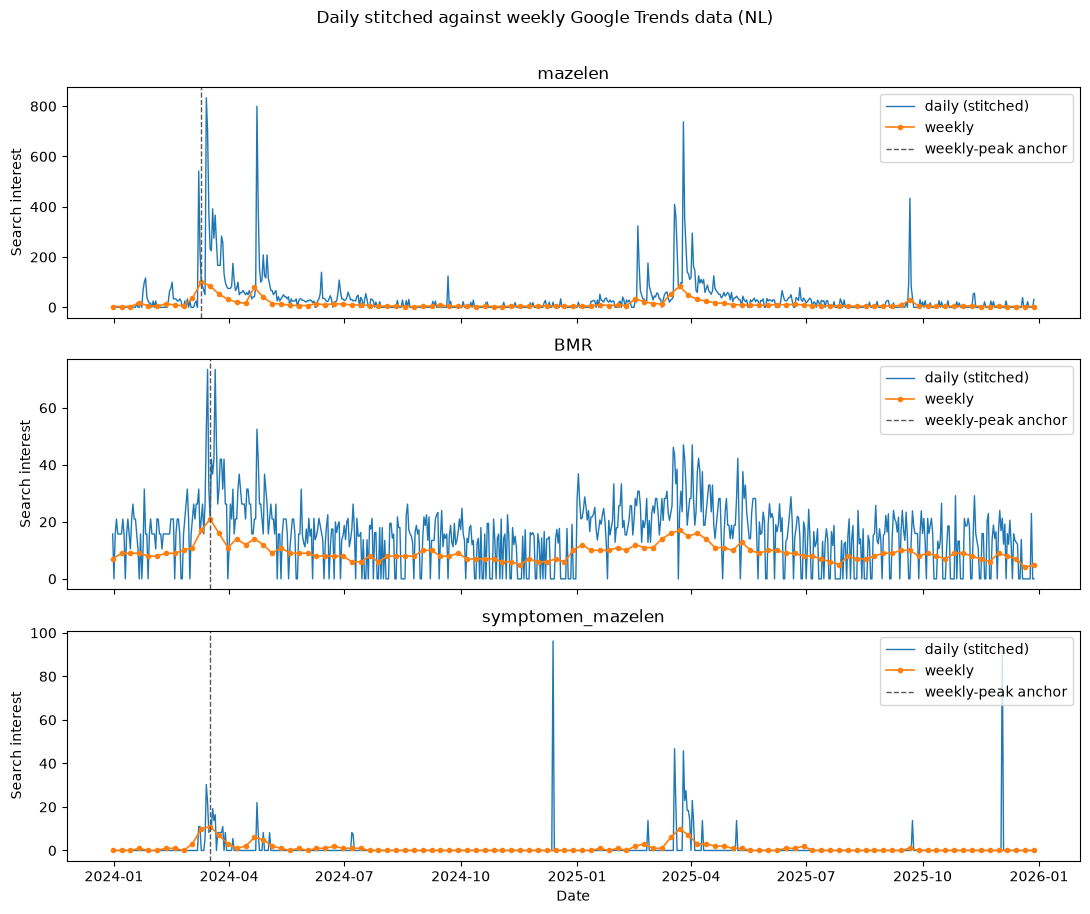

Date range: 2023-12-31 to 2025-12-28 (729 observed days)
Missing calendar dates: 0

Per-query validation:


,query,peak_date,peak_value,zero_value_days_pct,seasonality,highest_mean_month,lowest_mean_month,peak_to_trough_monthly_ratio
0,mazelen,2024-03-14,833.333333,48.3,likely,3,8,63.75
1,BMR,2024-03-15,73.500000,23.6,likely,3,12,3.78
2,symptomen_mazelen,2024-12-13,96.250000,94.5,likely,3,1,inf


Seasonality is a heuristic: at least two calendar years and a >=1.5x difference between highest and lowest mean month.


In [7]:
def gt_fetch_daily_stitched(kw_list, weekly_data, geo, window_days=90, overlap_days=30):
    """Fetch daily Trends windows, stitch their overlaps, and anchor to weekly data.

    Each short request supplies daily values. Consecutive windows overlap so their
    median ratio can put them on one scale. Finally, each column is calibrated to
    the date where its weekly series reaches its maximum.
    """
    if not 0 < overlap_days < window_days:
        raise ValueError('overlap_days must be greater than 0 and less than window_days')

    columns = [column for column in weekly_data.columns if column != 'date']
    weekly = weekly_data[['date', *columns]].copy()
    weekly['date'] = pd.to_datetime(weekly['date'])
    start, end = weekly['date'].min().normalize(), weekly['date'].max().normalize()

    windows = []
    window_start = start
    while window_start <= end:
        window_end = min(window_start + pd.Timedelta(days=window_days - 1), end)
        windows.append((window_start, window_end))
        if window_end == end:
            break
        window_start = window_end - pd.Timedelta(days=overlap_days - 1)

    daily_frames = []
    for number, (window_start, window_end) in enumerate(windows, start=1):
        timeframe = f'{window_start:%Y-%m-%d} {window_end:%Y-%m-%d}'
        print(f'Daily window {number}/{len(windows)}: {timeframe}')
        frame = gt_fetch(kw_list, timeframe=timeframe, geo=geo)
        if frame is None:
            print('Daily pull incomplete; no stitched daily series returned.')
            return None, None
        frame['date'] = pd.to_datetime(frame['date'])
        daily_frames.append(frame[['date', *columns]])

    stitched = daily_frames[0].set_index('date').sort_index()
    for incoming_frame in daily_frames[1:]:
        incoming = incoming_frame.set_index('date').sort_index()
        shared_dates = stitched.index.intersection(incoming.index)
        for column in columns:
            overlap = pd.concat(
                [stitched.loc[shared_dates, column], incoming.loc[shared_dates, column]],
                axis=1, keys=['old', 'new'],
            ).dropna()
            overlap = overlap[(overlap['old'] > 0) & (overlap['new'] > 0)]
            if not overlap.empty:
                incoming[column] *= (overlap['old'] / overlap['new']).median()
            else:
                print(f'No nonzero overlap for {column}; leaving this window unscaled.')
        stitched = stitched.combine_first(incoming)

    anchor_rows = []
    for column in columns:
        anchor_date = weekly.loc[weekly[column].idxmax(), 'date']
        weekly_value = weekly.loc[weekly['date'] == anchor_date, column].iloc[0]
        nearest = stitched.index.get_indexer([anchor_date], method='nearest')[0]
        daily_value = stitched.iloc[nearest][column]
        if pd.notna(daily_value) and daily_value > 0:
            stitched[column] *= weekly_value / daily_value
        else:
            print(f'Could not anchor {column}: daily value is zero or missing.')
        anchor_rows.append({
            'query': column, 'anchor_date': anchor_date,
            'weekly_value': weekly_value, 'daily_value_before_scaling': daily_value,
        })

    return stitched.reset_index(), pd.DataFrame(anchor_rows)


def validate_daily_trends(daily_data):
    """Print coverage, peaks, zeros, and a simple month-of-year seasonality check."""
    data = daily_data.copy()
    data['date'] = pd.to_datetime(data['date'])
    data = data.sort_values('date')
    columns = [column for column in data.columns if column != 'date']

    observed_dates = pd.DatetimeIndex(data['date'].drop_duplicates())
    expected_dates = pd.date_range(observed_dates.min(), observed_dates.max(), freq='D')
    missing_dates = expected_dates.difference(observed_dates)
    print(f'Date range: {observed_dates.min().date()} to {observed_dates.max().date()} ({len(observed_dates)} observed days)')
    print(f'Missing calendar dates: {len(missing_dates)}')
    if len(missing_dates):
        print('First missing dates:', ', '.join(date.strftime('%Y-%m-%d') for date in missing_dates[:10]))

    month_means = data.assign(month=data['date'].dt.month).groupby('month')[columns].mean()
    summary_rows = []
    for column in columns:
        peak_row = data.loc[data[column].idxmax()]
        zero_percent = data[column].eq(0).mean() * 100
        peak_month = month_means[column].idxmax()
        trough_month = month_means[column].idxmin()
        trough_mean = month_means.loc[trough_month, column]
        peak_to_trough = month_means.loc[peak_month, column] / trough_mean if trough_mean > 0 else float('inf')
        years_covered = data['date'].dt.year.nunique()
        seasonal = years_covered >= 2 and peak_to_trough >= 1.5
        summary_rows.append({
            'query': column, 'peak_date': peak_row['date'].date(), 'peak_value': peak_row[column],
            'zero_value_days_pct': round(zero_percent, 1),
            'seasonality': 'likely' if seasonal else 'not clear',
            'highest_mean_month': peak_month, 'lowest_mean_month': trough_month,
            'peak_to_trough_monthly_ratio': round(peak_to_trough, 2),
        })
    report = pd.DataFrame(summary_rows)
    print('\nPer-query validation:')
    display(report)
    print('Seasonality is a heuristic: at least two calendar years and a >=1.5x difference between highest and lowest mean month.')
    return report, missing_dates


series = gt_fetch(MY_TERMS, timeframe=RECENT_TF, geo=MY_GEO)
if series is None:
    series = load_cached_example()

# Resolve the first phrase to Google's topic entity, then pull that entity by its mid.
topic_query = MY_TERMS[0]
mid, topic_title, topic_type = topic_mid(topic_query)
print(f'Topic for {topic_query!r}: {topic_title!r} ({topic_type}), mid={mid}')
topic_series = gt_fetch([mid], timeframe=RECENT_TF, geo=MY_GEO) if mid != topic_query else None
if topic_series is None:
    print('Topic series unavailable; plotting the query phrases only.')

query_columns = [column for column in series.columns if column != 'date']
print(f'Rows: {len(series)} | last date: {series["date"].max().date()}')

fig, ax = plt.subplots(figsize=(10, 4))
for column in query_columns:
    ax.plot(series['date'], series[column], label=column)
if topic_series is not None:
    topic_column = next(column for column in topic_series.columns if column != 'date')
    ax.plot(topic_series['date'], topic_series[topic_column], color='black', linewidth=2.5,
            label=f'topic: {topic_title}')
ax.set(title=f'Google Trends queries and topic in {MY_GEO}', xlabel='Date', ylabel='Search interest (0-100)')
ax.legend()
fig.tight_layout()
plt.show()

series.tail()

# Daily Trends requests are limited to short windows. This may take several minutes
# for five years of data because it makes approximately one request per 60 days.
daily_series, anchor_dates = gt_fetch_daily_stitched(MY_TERMS, series, MY_GEO)
if daily_series is not None:
    print('Weekly-peak anchors used to calibrate the daily series:')
    display(anchor_dates)

    fig, axes = plt.subplots(len(query_columns), 1, figsize=(11, 3 * len(query_columns)), sharex=True)
    axes = [axes] if len(query_columns) == 1 else axes
    for ax, column in zip(axes, query_columns):
        ax.plot(daily_series['date'], daily_series[column], color='tab:blue', linewidth=1, label='daily (stitched)')
        ax.plot(series['date'], series[column], color='tab:orange', marker='o', markersize=3,
                linewidth=1.2, label='weekly')
        anchor_date = anchor_dates.loc[anchor_dates['query'] == column, 'anchor_date'].iloc[0]
        ax.axvline(anchor_date, color='0.35', linestyle='--', linewidth=1, label='weekly-peak anchor')
        ax.set(title=column, ylabel='Search interest')
        ax.legend(loc='upper right')
    axes[-1].set_xlabel('Date')
    fig.suptitle(f'Daily stitched against weekly Google Trends data ({MY_GEO})', y=1.01)
    fig.tight_layout()
    plt.show()

    validation_report, missing_daily_dates = validate_daily_trends(daily_series)


## Step 1b: compare against reported cases in NL
Please read in the data I've added to my data folder of weekly reported measles cases by week (Aantal Infectieziektes....); please note that the months are abbreviated in Dutch. When read in and formatted to standard universal dates, please compare the trends data to the reported data in several ways: please provide me the correlation, the minimum and maximum identified lags, and please plot them on the same time series, using the same minima and maxima. 


Case file: Aantal Infectieziektes over tijd (1).csv; 27 weeks with one or more reported Mazelen cases.
Overlapping weekly range: 2024-01-07 to 2025-12-28 (104 weeks)
Correlation at zero lag — Pearson: 0.400; Spearman: 0.391
Maximum correlation: 0.428 at +1 weeks (searches lead when positive).
Minimum correlation: -0.119 at -8 weeks (searches lead when positive).


,lag_weeks,n_weeks,pearson_correlation
0,-8,96,-0.119173
1,-7,97,-0.110294
2,-6,98,-0.085226
3,-5,99,-0.042087
4,-4,100,0.016651
5,-3,101,0.084545
6,-2,102,0.149001
7,-1,103,0.262333
8,0,104,0.399793
9,1,103,0.427874


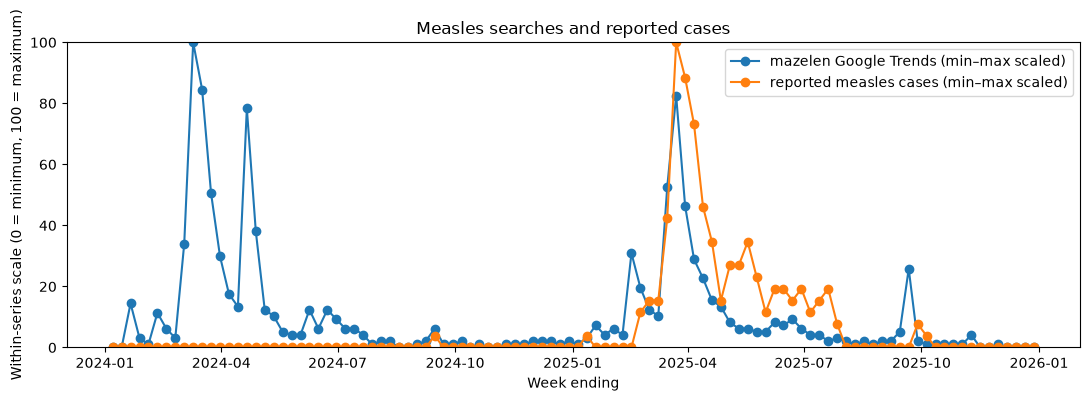

In [12]:
# Agent's live pull (with cache fallback):


## Step 2: term vs topic (the language lesson)

> *The API accepts a literal term or a Knowledge Graph topic id. For each of US, FR, IT and*
> *MX, pull 'flu' and '/m/0cycc' (Influenza) in one call and tabulate the max and mean of*
> *each. Then plot both series for France.*

**What you should see:** the English term is nearly silent outside the US, while the topic
tracks the flu season everywhere, because it covers *grippe*, *influenza* and *gripe* alike.
That is why cross-country work uses topics.


In [14]:
# Compare literal terms, one additive query, and the Google Trends topic entity.
individual = gt_fetch(MY_TERMS, timeframe=RECENT_TF, geo=MY_GEO)
combined_query = ' + '.join(MY_TERMS)
combined = gt_fetch([combined_query], timeframe=RECENT_TF, geo=MY_GEO)
mid, topic_title, topic_type = topic_mid(MY_TERMS[0])
print(f'Topic for {MY_TERMS[0]!r}: {topic_title!r} ({topic_type}), mid={mid}')
topic = gt_fetch([mid], timeframe=RECENT_TF, geo=MY_GEO) if mid != MY_TERMS[0] else None

comparison_rows = []
plot_series = []
if individual is not None:
    individual_columns = [column for column in individual.columns if column != 'date']
    for column in individual_columns:
        comparison_rows.append({'signal': f'term: {column}', 'zero_pct': round(individual[column].eq(0).mean() * 100, 1)})
        plot_series.append((individual, column, f'term: {column}', 0.5, None))
if combined is not None:
    combined_column = next(column for column in combined.columns if column != 'date')
    comparison_rows.append({'signal': f'additive: {combined_query}',
                            'zero_pct': round(combined[combined_column].eq(0).mean() * 100, 1)})
    plot_series.append((combined, combined_column, f'additive: {combined_query}', 1.0, 'black'))
if topic is not None:
    topic_column = next(column for column in topic.columns if column != 'date')
    comparison_rows.append({'signal': f'topic: {topic_title}', 'zero_pct': round(topic[topic_column].eq(0).mean() * 100, 1)})
    plot_series.append((topic, topic_column, f'topic: {topic_title}', 1.0, 'tab:red'))

zero_comparison = pd.DataFrame(comparison_rows, columns=['signal', 'zero_pct'])
if zero_comparison.empty:
    print('No comparison series were returned. Google Trends rate-limited this run; wait a few minutes before trying again.')
else:
    zero_comparison = zero_comparison.sort_values('zero_pct').reset_index(drop=True)
    display(zero_comparison)
    print(f'Fewest zeros: {zero_comparison.iloc[0]["signal"]} ({zero_comparison.iloc[0]["zero_pct"]:.1f}%).')

if plot_series:
    fig, ax = plt.subplots(figsize=(11, 4))
    for frame, column, label, alpha, color in plot_series:
        ax.plot(frame['date'], frame[column], label=label, alpha=alpha, color=color)
    ax.set(title=f'Google Trends signal choices for {MY_TERMS[0]} ({MY_GEO})', xlabel='Date', ylabel='Search interest (0-100)')
    ax.legend()
    fig.tight_layout()
    plt.show()

    # A month-of-year contrast is a compact seasonal-signal check, not a formal test.
    zero_rates = dict(zip(zero_comparison['signal'], zero_comparison['zero_pct']))
    seasonality_rows = []
    for frame, column, label, _, _ in plot_series:
        month_means = frame.assign(month=pd.to_datetime(frame['date']).dt.month).groupby('month')[column].mean()
        low = month_means.min()
        contrast = month_means.max() / low if low > 0 else float('inf')
        seasonality_rows.append({'signal': label, 'zero_pct': zero_rates[label], 'peak_month': month_means.idxmax(),
                                 'monthly_peak_to_trough_ratio': round(contrast, 2)})
    seasonality_comparison = pd.DataFrame(seasonality_rows).sort_values('monthly_peak_to_trough_ratio', ascending=False)
    display(seasonality_comparison)
    usable_seasonality = seasonality_comparison[seasonality_comparison['zero_pct'] <= 5]
    cleanest = usable_seasonality.iloc[0] if not usable_seasonality.empty else seasonality_comparison.iloc[0]
    print(f'Among signals with <=5% zero weeks, the clearest seasonal pattern is {cleanest["signal"]} (ratio {cleanest["monthly_peak_to_trough_ratio"]}).')


Rate-limited (1/4); waiting about 10 seconds...
Rate-limited (2/4); waiting about 10 seconds...
Rate-limited (3/4); waiting about 10 seconds...
Google Trends pull failed (RetryError): HTTPSConnectionPool(host='www.google.com', port=443): Max retries exceeded with url: /sorry/index?continue=https://trends.google.com/trends/api/explore%3Fhl%3Den-US%26tz%3D360%26req%3D%257B%2522comparisonItem%2522%253A%2B%255B%257B%2522keyword%2522%253A%2B%2522mazelen%2522%252C%2B%2522time%2522%253A%2B%25222024-01-01%2B2026-01-01%2522%252C%2B%2522geo%2522%253A%2B%2522NL%2522%257D%252C%2B%257B%2522keyword%2522%253A%2B%2522BMR%2522%252C%2B%2522time%2522%253A%2B%25222024-01-01%2B2026-01-01%2522%252C%2B%2522geo%2522%253A%2B%2522NL%2522%257D%252C%2B%257B%2522keyword%2522%253A%2B%2522symptomen%2Bmazelen%2522%252C%2B%2522time%2522%253A%2B%25222024-01-01%2B2026-01-01%2522%252C%2B%2522geo%2522%253A%2B%2522NL%2522%257D%255D%252C%2B%2522category%2522%253A%2B0%252C%2B%2522property%2522%253A%2B%2522%2522%257D&hl=en-US

## Step 3: prove it is reproducible

> *Pull the same series twice and check whether the two results are identical.*

**Why it matters:** `pytrends` reads a *sampled* public endpoint, so repeat pulls
disagree and it rate-limits you. The API is deterministic, which is what makes an
analysis reproducible.


In [ ]:
# Agent's twice-pulled comparison:


Rate-limited (1/4); waiting about 10 seconds...
Rate-limited (2/4); waiting about 10 seconds...
Rate-limited (3/4); waiting about 10 seconds...
Google Trends pull failed (RetryError): HTTPSConnectionPool(host='www.google.com', port=443): Max retries exceeded with url: /sorry/index?continue=https://trends.google.com/trends/api/explore%3Fhl%3Den-US%26tz%3D360%26req%3D%257B%2522comparisonItem%2522%253A%2B%255B%257B%2522keyword%2522%253A%2B%2522mazelen%2522%252C%2B%2522time%2522%253A%2B%25222024-01-01%2B2026-01-01%2522%252C%2B%2522geo%2522%253A%2B%2522NL%2522%257D%255D%252C%2B%2522category%2522%253A%2B0%252C%2B%2522property%2522%253A%2B%2522%2522%257D&hl=en-US&q=EgSH7YLtGP6H-tIGIi96H3UzpRgKN7iU254k9p9HR0vRW4n5QmpOxz38r8IR8CbO4s_n9LJc22nUyfDDPzICclJaAUM (Caused by ResponseError('too many 429 error responses'))
Rate-limited (1/4); waiting about 10 seconds...
Rate-limited (2/4); waiting about 10 seconds...
Rate-limited (3/4); waiting about 10 seconds...


## Step 4: sanity-check and save

> *Report the geo, date range, row count, resolution, missing values and percent zeros*
> *per column. Then save the tidy table to my_topic_search.csv.*


In [16]:
# Agent's sanity-check + save:


Geo: NL
Date range: 2023-12-31 to 2025-12-28
Rows: 105
Missing values per column:


,missing_values
date,0
mazelen,0
BMR,0
symptomen_mazelen,0


Terms that vary (standard deviation > 0):


,standard_deviation
mazelen,18.065652
BMR,2.912270
symptomen_mazelen,2.174275


Saved /workspaces/sismid2026/day1-1530-ai-agents-data-scraping/data/mazelen_NL_search.csv (105 rows; columns: ['date', 'mazelen', 'BMR', 'symptomen_mazelen'])


## Reflection

- Same signal as `pytrends`, delivered reliably and reproducibly.
- **Quota and etiquette:** 1,000 requests/day on the class key, health-related topics
  only, and never commit the key.
- **Day 2:** the same loop for Wikipedia, wastewater, mobility, weather and news.
